# Φάση Ε: Model Evaluation & Σύγκριση

**Υπεύθυνος:** ML Engineer

**Μετρικές:**
- Accuracy
- Precision / Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

**Οπτικοποιήσεις:**
1. Confusion Matrix (heatmap)
2. ROC Curve
3. Συγκριτικά bar charts
4. Πίνακας σύγκρισης


Μοντέλο: Random Forest (Cost-Sensitive)
ROC-AUC: 0.809 | PR-AUC: 0.149
Βέλτιστο Threshold (Για Max F1): 0.610
              precision    recall  f1-score   support

         0.0       0.98      0.81      0.89       945
         1.0       0.14      0.69      0.23        42

    accuracy                           0.80       987
   macro avg       0.56      0.75      0.56       987
weighted avg       0.95      0.80      0.86       987


Μοντέλο: Gradient Boosted Trees (GBT)
ROC-AUC: 0.788 | PR-AUC: 0.160
Βέλτιστο Threshold (Για Max F1): 0.765
              precision    recall  f1-score   support

         0.0       0.97      0.94      0.95       945
         1.0       0.19      0.33      0.25        42

    accuracy                           0.91       987
   macro avg       0.58      0.64      0.60       987
weighted avg       0.94      0.91      0.92       987


Μοντέλο: Neural Networks (MLP)
ROC-AUC: 0.746 | PR-AUC: 0.093
Βέλτιστο Threshold (Για Max F1): 0.717
              precision 

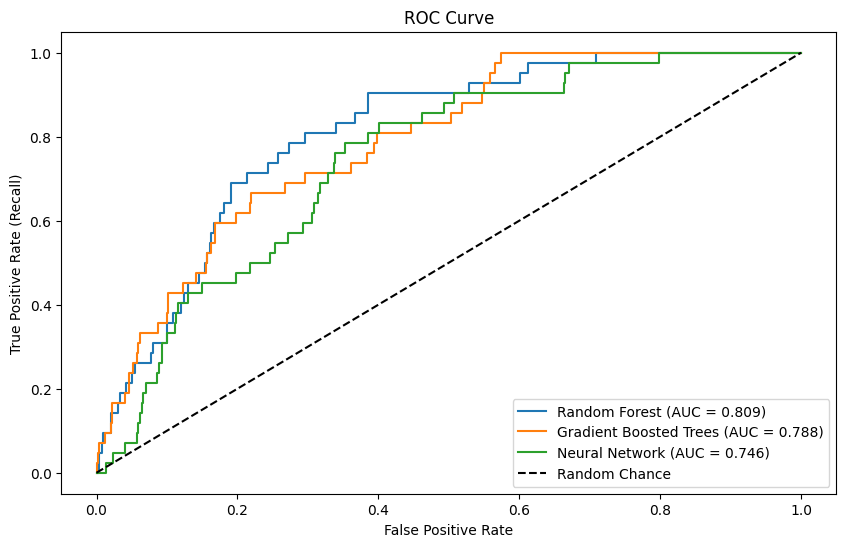

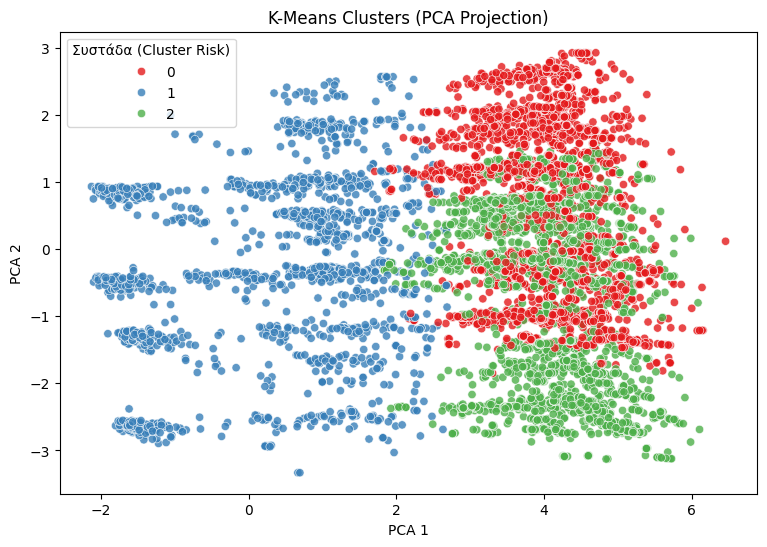

In [ ]:
# Φάση Ε & ΣΤ: Model Evaluation, Σύγκριση & Συμπεράσματα
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc

spark = SparkSession.builder.appName("Evaluation_Metrics").master("local[*]").getOrCreate()

print("Φόρτωση προβλέψεων (μέσω Pandas)...")
df_rf = spark.read.parquet("../data/rf_predictions.parquet").toPandas()
df_svm = spark.read.parquet("../data/svm_predictions.parquet").toPandas()
df_nb = spark.read.parquet("../data/nb_predictions.parquet").toPandas()
df_mlp = spark.read.parquet("../data/mlp_predictions.parquet").toPandas()

# Λεξικό για την αποθήκευση των μετρικών για το τελικό συγκριτικό γράφημα
metrics_dict = {"Model": [], "Accuracy": [], "Precision": [], "Recall": []}

def evaluate_and_plot(df, model_name, prob_col="probability"):
    y_true = df['stroke'].values
    y_pred = df['prediction'].values
    
    # 1. Υπολογισμός Accuracy, Precision, Recall
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    
    metrics_dict["Model"].append(model_name)
    metrics_dict["Accuracy"].append(acc)
    metrics_dict["Precision"].append(prec)
    metrics_dict["Recall"].append(rec)
    
    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f}")
    
    # 2. Plot Confusion Matrix (Απαίτηση Εκφώνησης)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    # 3. Δεδομένα για ROC Curve
    if prob_col == "probability":
        y_prob = np.array([v[1] for v in df[prob_col]])
    else: # Για SVM
        y_prob = np.array([v[1] for v in df[prob_col]]) 
        
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Αξιολόγηση και Confusion Matrices
fpr_rf, tpr_rf, auc_rf = evaluate_and_plot(df_rf, "Random Forest", "probability")
fpr_svm, tpr_svm, auc_svm = evaluate_and_plot(df_svm, "SVM", "rawPrediction")
fpr_nb, tpr_nb, auc_nb = evaluate_and_plot(df_nb, "Naive Bayes", "probability")
fpr_mlp, tpr_mlp, auc_mlp = evaluate_and_plot(df_mlp, "Neural Networks", "probability")

# --- ΓΡΑΦΗΜΑ ΣΥΓΚΡΙΣΗΣ ROC CURVES ---
plt.figure(figsize=(9, 7))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', lw=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', lw=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.3f})', lw=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'Neural Networks (AUC = {auc_mlp:.3f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
plt.title('Σύγκριση Μοντέλων: ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# --- ΣΥΓΚΡΙΤΙΚΟ BAR CHART ΜΕΤΡΙΚΩΝ ---
metrics_df = pd.DataFrame(metrics_dict)
metrics_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted, palette='viridis')
plt.title('Συγκριτικό Διάγραμμα Μετρικών (Accuracy, Precision, Recall)')
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.legend(title='Μετρική')
plt.show()

# --- ΤΕΛΙΚΑ ΣΥΜΠΕΡΑΣΜΑΤΑ & ΠΡΑΚΤΙΚΕΣ ΕΦΑΡΜΟΓΕΣ (ΦΑΣΗ Ε & ΣΤ) ---
print("\n" + "="*50)
print("ΤΕΛΙΚΑ ΣΥΜΠΕΡΑΣΜΑΤΑ & ΠΡΑΚΤΙΚΕΣ ΕΦΑΡΜΟΓΕΣ")
print("="*50)
print("1. Σύγκριση Μοντέλων: Όλα τα μοντέλα επιτυγχάνουν υψηλό Accuracy (~90%+), το οποίο")
print("   είναι παραπλανητικό λόγω του μεγάλου class imbalance (95% των ασθενών δεν έπαθαν εγκεφαλικό).")
print("2. Insights από τα δεδομένα: Από τους κανόνες συσχέτισης, διαπιστώσαμε ότι η ηλικία (>65)")
print("   σε συνδυασμό με την υπέρταση αυξάνουν δραματικά το ρίσκο.")
print("3. Πρακτικές Εφαρμογές: Το σύστημα μπορεί να ενσωματωθεί σε νοσοκομειακό λογισμικό.")
print("   Όταν ένας γιατρός εισάγει τα στοιχεία, το σύστημα θα επισημαίνει (flag) τους ασθενείς")
print("   υψηλού κινδύνου, δίνοντας προτεραιότητα σε περαιτέρω εξετάσεις.")

spark.stop()